# Prac 03. Part 1

For this homework you are going to implement the **unsharp masking** filter (USM). It is a technique to improve the sharpness of an image by combining the image with its blurred (unsharp) version. See the Wikipedia [page](https://en.wikipedia.org/wiki/Unsharp_masking) for more details.

### Unsharp Masking (USP)
The USM technique consists of the following steps:
* Load the image you will be working with.
* Create a blurred (unsharp) version of the original image.
* Add the unsharp image (with a certain **weight**) to the original.

To sum it up, the USM performs the following operation:

`sharpened = original + (original − unsharp) × amount`

Even though we provide you an image to work with, you are welcome to use your own images :-)

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

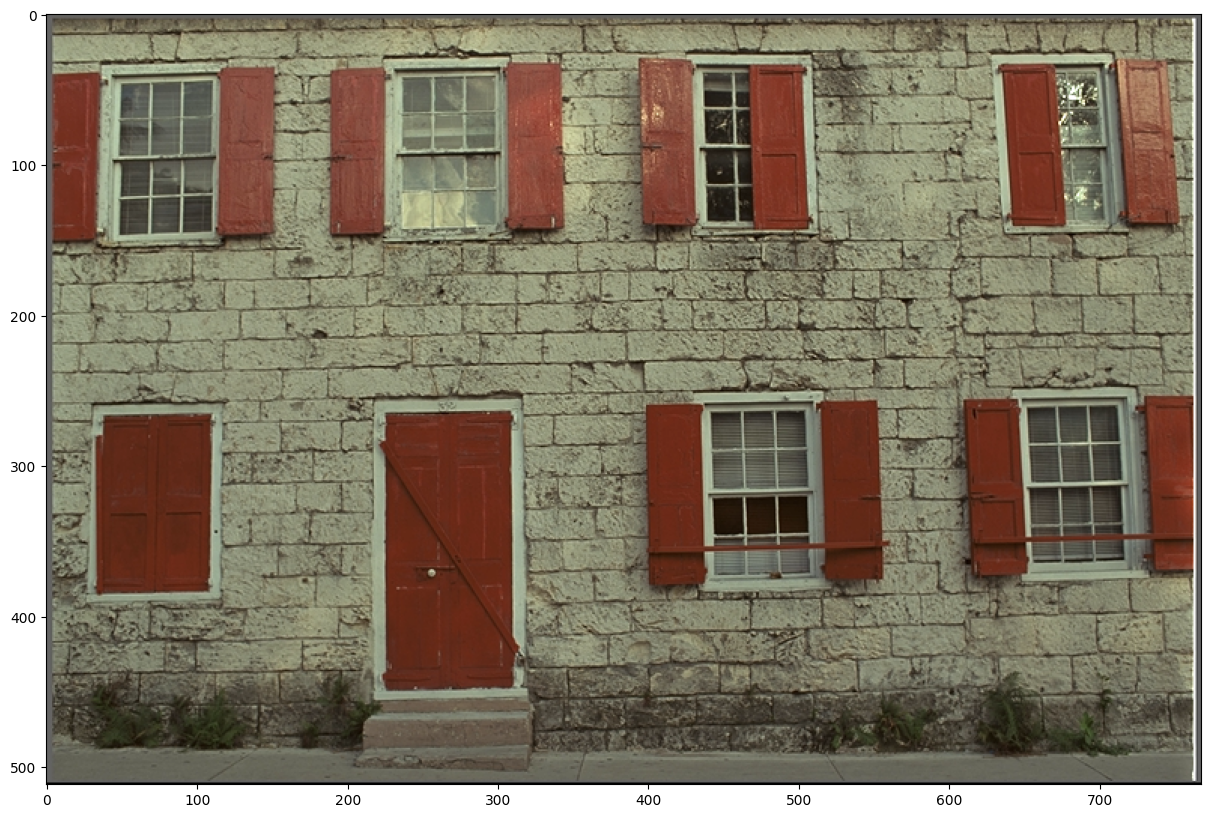

In [2]:
img = cv2.imread('../data/kodim01.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

In [3]:
# Create a blurred (unsharp) version of the original image (you can use Gaussian blurring)
unsharp = cv2.GaussianBlur(img, ksize=(5, 5), sigmaX=5)

In [4]:
# Create the difference image (original − unsharp)
# Note: Remember that you are working with uint8 data types. Any addition or substractions
# might result in overflow or underflow, respectively. You can prevent this by casting the images to float.
diff = img.astype(np.float32) - unsharp.astype(np.float32)

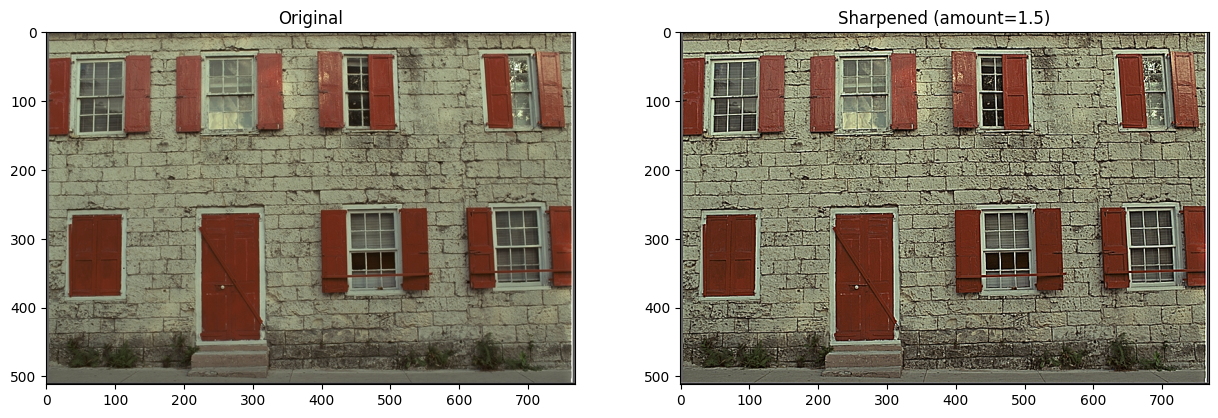

In [10]:
# Apply USM to get the resulting image using `sharpened = original + (original − unsharp) × amount`
# Note: Again, take care of underflows/overflows if necessary.
amount = 1.5

sharpened = img.astype(np.float32) + diff * amount

sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

plt.subplot(121), plt.imshow(img), plt.title('Original')
plt.subplot(122), plt.imshow(sharpened), plt.title(f'Sharpened (amount={amount})')
plt.show()

### Questions
* What is a good (reasonable) value for the `amount` parameter?

Usually, the optimal value for amount lies in the range of 0.5 to 2.0, depending on how strongly we want to emphasize the details. A value of 1.0 – 1.5 is a good starting point.

 * What happens if it is too small?

If the value is too small (for example close to 0), the sharpening effect will be almost unnoticeable, and the image will remain virtually the same as the original.

 * What happens if it is too large?

If the value is too large, unwanted artifacts will appear: unnatural bright and dark halos will form around edges, digital noise will be significantly amplified, and the image will look over-sharpened, overexposed and unnatural.